# TianoCore Survey EDA
## Section 5: Testing & Analysis Tools (Q32–Q46)

---
Survey period: March 8–25, 2026 | Participants: 13

### Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Step 2 — Install dependencies

In [2]:
!pip install matplotlib pandas -q

### Step 3 — Setup: load data and helpers

In [3]:
import os, re, pandas as pd, matplotlib.pyplot as plt
from collections import Counter, OrderedDict

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/TS-Survey/tianocore-survey_cleaned.csv"
OUT_DIR  = "/content/drive/MyDrive/TS-Survey/figures"
os.makedirs(OUT_DIR, exist_ok=True)

C_MAIN   = "#ffb07c"
C_SECOND = "#B4B2A9"
PIE_PALETTE = ["#ffb07c","#FFF4B3","#FFD7EE","#FAC775","#F0997B","#97C459","#B4B2A9"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "x",
    "grid.color": "#ebebeb", "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "xtick.labelsize": 9, "ytick.labelsize": 10,
})

df = pd.read_csv(CSV_PATH, header=0, skiprows=[1, 2])
N  = len(df)

# Exact choices from QSF — used to split multi-select responses correctly
QSF_CHOICES = {'Q1': ['Original Equipment Manufacturer (OEM)', 'Independent Firmware/BIOS Vendor', 'Another role in industry (e.g., firmware security expert/practitioner)', 'Another role in academia (e.g., researcher)', 'I do not know about TianoCore.', 'I know about TianoCore, but I do not belong to this ecosystem.', 'Others (please specify)'], 'Q5': ['Jira', 'GitHub Issues', 'GitLab Issues', 'Bugzilla', 'Azure DevOps', 'Other'], 'Q6': ['It is access-restricted (e.g., requires approval, access allowed to only employees, etc.).', 'Open Access: It is open with read access for everyone, and everyone can report a new issue.', 'Open Read Access but Restricted Write Access (a): It is open to everyone for read access, but only specific people can report new issues.', 'Open Read Access but Restricted Write Access (b): It is open to everyone for read access and write access to report new issues, but only specific people can update the reported issues (e.g., adding comments or changing fields).'], 'Q8': ['Bug Description (What is the issue? Expected behavior vs. observed behavior)', 'Proof of Concept (PoC) or Steps to Reproduce', 'Target Environment (System/hardware configuration where the bug is observed)', 'Impact (How exactly does the bug affect the functionality of the firmware)', 'Potential Patch or Fix suggestion', 'Suggested CVSS and CWE scoring', 'Files and packages impacted', 'Affected versions', 'Bug introducing commit', 'Others (please explain)'], 'Q9': ['Severity (e.g., potentially affecting many users/organizations)', 'Availability of steps to reproduce (i.e., a concrete case is available for the bug)', 'Availability of proposed patch', 'Availability of unit test / PoC / other test cases', 'Type of fix (e.g., easy fix vs. architecture design change)', 'Active maintainer for the given subsystem', 'Others (please explain)'], 'Q13': ['Always', 'Only for security bugs', 'Only for bugs affecting core functionality', "At the developers' discretion", 'Others (please explain)'], 'Q14': ['Upstream issue tracker associated with the repository (e.g., trackers from question Q3)', 'Security mailing lists', "Through a vendor's website", 'Informal communication (e.g., email)', 'Others (please explain)', 'Not applicable (i.e., we do not explicitly report to upstream)'], 'Q29': ['Bug fixes', 'Security fixes', 'Refactorings or cleanups', 'Feature additions'], 'Q38': ['Compiler-based warnings', 'Commercial SAST tools', 'Open-source static analyzers', 'Semantic/code-query tools', 'None'], 'Q54': ['Toolchain limitations', 'Performance concerns', 'Integration with existing C code', 'Lack of internal expertise', 'Other'], 'Q62': ['Automated build verification', 'Automated regression testing', 'Static analysis / SAST', 'Dynamic analysis / fuzzing', 'Security policy or compliance checks', 'Automated issue or alert generation', 'Others (please specify)'], 'Q63': ['Atlassian Bamboo', 'Azure Pipelines', 'Buildkite', 'CircleCI', 'Concourse', 'GitHub Actions (Workflows)', 'GitLab CI/CD', 'GoCD', 'Jenkins', 'Screwdriver', 'Spinnaker', 'TeamCity', 'Tekton Pipelines', 'Travis CI', 'Others (please specify)'], 'Q65': ['Manual review of upstream code or releases', 'Tracking dependencies using internal documentation or spreadsheets', 'Monitoring CVEs or vulnerability databases', 'Automated dependency or supply-chain scanning tools', 'Vendor-provided assurances or certifications', 'We do not perform explicit supply-chain verification'], 'Q66': ['Limited tooling support', 'Lack of standardized metadata', 'Scale or complexity of dependencies', 'Limited staffing or expertise', 'Performance or integration concerns', 'No major challenges', 'Other'], 'Q71': ['Open-source firmware development (e.g., TianoCore/EDK II)', 'Proprietary firmware development based on TianoCore/UEFI', 'Firmware security analysis or auditing', 'Research or experimental firmware development', 'Tooling or infrastructure supporting firmware development (e.g., CI, testing, or analysis)', 'Legal, policy, and/or compliance', 'Others (please specify)'], 'Q72': ['Firmware developer', 'Firmware PSIRT/SSDLC, security engineer, analyzer, tester, or reviewer', 'Firmware maintainer', 'Tool developer for firmware testing, analysis, or DevOps/DevSecOps', 'Project manager or technical lead', 'Researcher', 'Others (please specify)'], 'Q80': ['Lack of expertise or training', 'Cost of tools or infrastructure', 'Complexity of firmware security tooling', 'Limited documentation or educational resources', 'Competing operational priorities', 'No significant barriers', "Don't know", 'Other'], 'Q81': ['Better documentation and tutorials', 'Open-source security analysis tools', 'Training programs or workshops', 'Academic–industry collaboration', 'Automated security validation services', 'Other'], 'Q82': ['Increased engineering or remediation effort', 'Release delays or operational downtime', 'Compliance or certification overhead', 'Reputational or customer trust impact', 'Minimal or negligible impact', 'Not applicable', 'Other']}

def simple_counts(col):
    return Counter(df[col].dropna().tolist())

def multi_counts(col):
    """Split using exact QSF choices so no label is ever fragmented."""
    known = QSF_CHOICES.get(col, [])
    c = Counter()
    for val in df[col].dropna():
        val = str(val).strip()
        if not val or val == "nan":
            continue
        if known:
            # Greedy match against known choices (longest first)
            remaining = val
            found = []
            known_sorted = sorted(known, key=len, reverse=True)
            while remaining:
                matched = False
                for option in known_sorted:
                    if remaining.startswith(option):
                        found.append(option)
                        remaining = remaining[len(option):].lstrip(", ")
                        matched = True
                        break
                if not matched:
                    # fallback: take up to next comma+capital
                    m = re.search(r',(?=[A-Z])', remaining)
                    if m:
                        found.append(remaining[:m.start()].strip())
                        remaining = remaining[m.end():].strip()
                    else:
                        found.append(remaining.strip())
                        break
            for item in found:
                if item: c[item] += 1
        else:
            for item in re.split(r',(?=[A-Z])', val):
                item = item.strip()
                if item: c[item] += 1
    return c

# Only gray for exact catch-all labels
CATCHALL = ["others (please specify)", "other (please specify)", "others (please explain)",
            "other (please explain)", "other", "prefer not to say", "prefer to self-describe",
            "i do not know about tianocore.", "i know about tianocore, but i do not belong to this ecosystem.",
            "don't know", "no incentive needed", "not applicable", "none"]

def pick(label):
    return C_SECOND if label.lower().strip() in CATCHALL else C_MAIN

def save(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show(); plt.close(fig)
    print(f"Saved: {name}")

def hbar(cnt, fname, max_x=None, note=""):
    if not cnt: print(f"Skipped {fname} — no data"); return
    items  = list(cnt.items())
    labels = [i[0] for i in items]; vals = [i[1] for i in items]
    h = max(3.0, 0.7*len(items)+1.2)
    fig, ax = plt.subplots(figsize=(12, h))
    bars = ax.barh(labels[::-1], vals[::-1],
                   color=[pick(l) for l in labels[::-1]], height=0.5, zorder=3)
    ax.set_xlabel("Number of respondents", fontsize=10)
    ax.set_xlim(0, (max_x or max(vals))+1.5)
    ax.yaxis.set_tick_params(labelsize=10)
    for bar, v in zip(bars, vals[::-1]):
        if v > 0:
            ax.text(v+0.06, bar.get_y()+bar.get_height()/2,
                    str(v), va="center", fontsize=11, fontweight="bold")
    if note:
        fig.text(0.02, -0.04, f"Note: {note}", fontsize=8, color="#666", ha="left", style="italic")
    fig.subplots_adjust(left=0.45); save(fig, fname)

def pie(cnt, fname):
    if not cnt: print(f"Skipped {fname} — no data"); return
    items  = list(cnt.items())
    labels = [i[0] for i in items]; vals = [i[1] for i in items]
    colours = [PIE_PALETTE[i % len(PIE_PALETTE)] for i in range(len(items))]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    wedges, _, autotexts = ax.pie(vals, colors=colours, autopct="%1.0f%%",
                                   startangle=90, wedgeprops=dict(width=0.55), pctdistance=0.75)
    for at in autotexts: at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("black")
    ax.legend(wedges, [f"{l} ({v})" for l, v in zip(labels, vals)],
              loc="lower center", bbox_to_anchor=(0.5,-0.22), fontsize=9, frameon=False, ncol=2)
    fig.tight_layout(); save(fig, fname)

print(f"Loaded {N} participants. Helpers ready.")


Loaded 13 participants. Helpers ready.


## Q32 — Testing/Analysis Knowledge

Q32 — Testing Knowledge (n=8/13):
  No: 3
  Yes: 5


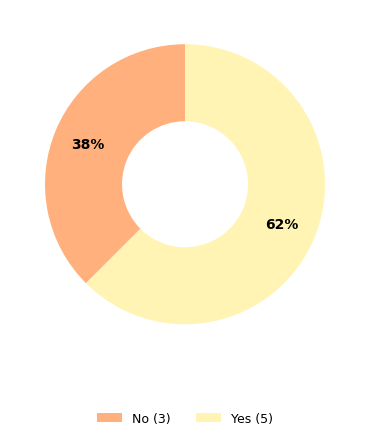

Saved: fig_38_testing_knowledge.png


In [4]:
q32 = simple_counts("Q32")
print(f"Q32 — Testing Knowledge (n={sum(q32.values())}/{N}):")
for k,v in q32.items(): print(f"  {k}: {v}")
pie(q32, "fig_38_testing_knowledge.png")


## Q33 — Formal Verification

Q33 — Formal Verification (n=5/13):
  No: 2
  Yes, as part of a regular workflow: 3


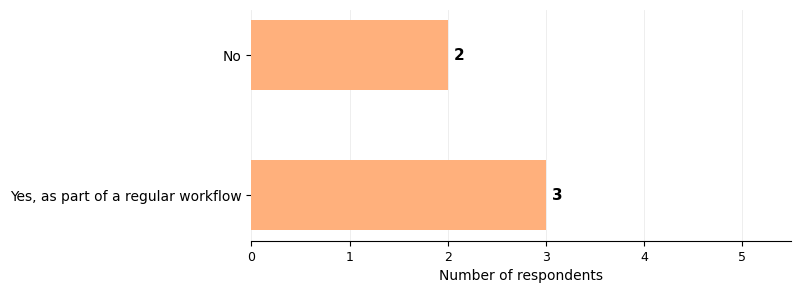

Saved: fig_39_formal_verification.png


In [5]:
fv_order = ["No","Yes, experimentally","Yes, for select components","Yes, as part of a regular workflow"]
fv_raw  = simple_counts("Q33")
fv_cnt  = OrderedDict((k, fv_raw[k]) for k in fv_order if k in fv_raw)
for k,v in fv_raw.items():
    if k not in fv_cnt: fv_cnt[k] = v
print(f"Q33 — Formal Verification (n={sum(fv_cnt.values())}/{N}):")
for k,v in fv_cnt.items(): print(f"  {k}: {v}")
hbar(fv_cnt, "fig_39_formal_verification.png", max_x=4)


## Q35 — Static Analysis Tools

Q35 — Static Analysis (n=5/13):
  No: 1
  Yes, manually and on demand: 2
  Yes, integrated into CI: 2


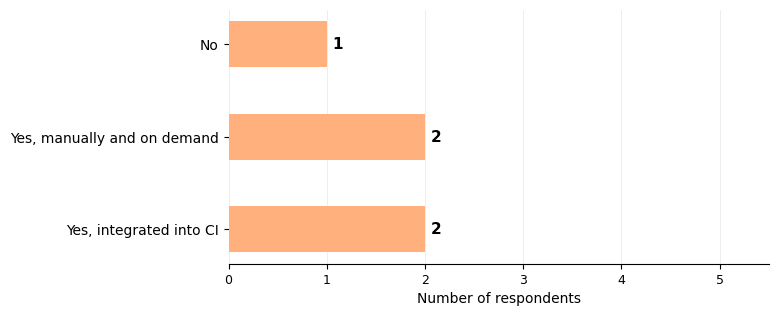

Saved: fig_40_static_analysis.png


In [6]:
sa_order = ["No","Yes, manually and on demand","Yes, integrated into CI","Yes, required by organizational policy"]
sa_raw  = simple_counts("Q35")
sa_cnt  = OrderedDict((k, sa_raw[k]) for k in sa_order if k in sa_raw)
for k,v in sa_raw.items():
    if k not in sa_cnt: sa_cnt[k] = v
print(f"Q35 — Static Analysis (n={sum(sa_cnt.values())}/{N}):")
for k,v in sa_cnt.items(): print(f"  {k}: {v}")
hbar(sa_cnt, "fig_40_static_analysis.png", max_x=4)


## Q38 — Types of Static Analysis Tools

Q38 — Static Analysis Types (n=5/13):
  Open-source static analyzers: 5
  Compiler-based warnings: 3
  Commercial SAST tools: 2
  Semantic/code-query tools: 1


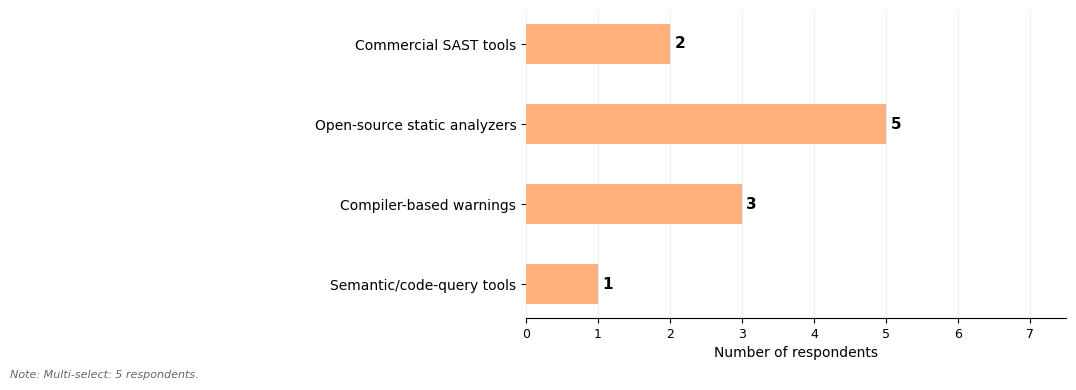

Saved: fig_41_static_types.png


In [7]:
q38 = multi_counts("Q38")
n_q38 = df["Q38"].notna().sum()
print(f"Q38 — Static Analysis Types (n={n_q38}/{N}):")
for k,v in q38.most_common(): print(f"  {k}: {v}")
hbar(q38, "fig_41_static_types.png", max_x=6,
     note=f"Multi-select: {n_q38} respondents.")


## Q39 — CodeQL Awareness

Q39 — CodeQL (n=5/13):
  Not aware of CodeQL: 2
  Aware, but do not use: 3


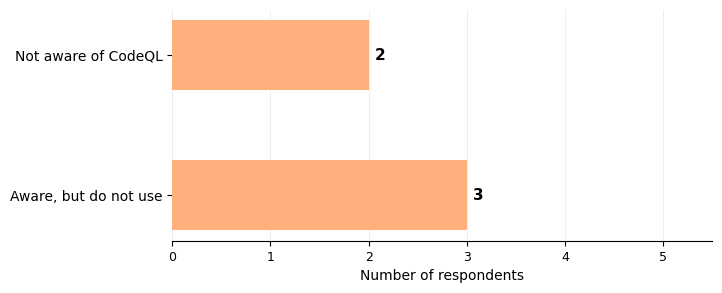

Saved: fig_42_codeql.png


In [8]:
cq_order = ["Not aware of CodeQL","Aware, but do not use","Use occasionally","Use regularly"]
cq_raw  = simple_counts("Q39")
cq_cnt  = OrderedDict((k, cq_raw[k]) for k in cq_order if k in cq_raw)
for k,v in cq_raw.items():
    if k not in cq_cnt: cq_cnt[k] = v
print(f"Q39 — CodeQL (n={sum(cq_cnt.values())}/{N}):")
for k,v in cq_cnt.items(): print(f"  {k}: {v}")
hbar(cq_cnt, "fig_42_codeql.png", max_x=4)


## Q41 — Dynamic Analysis

Q41 — Dynamic Analysis (n=5/13):
  Yes, integration/system testing: 2
  Yes, fuzzing: 2
  Yes, multiple forms of dynamic analysis: 1


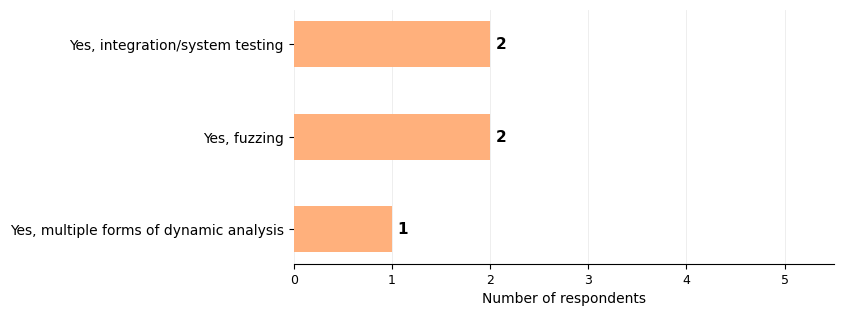

Saved: fig_43_dynamic_analysis.png


In [9]:
da_order = ["No","Yes, unit testing only","Yes, integration/system testing","Yes, fuzzing","Yes, multiple forms of dynamic analysis"]
da_raw  = simple_counts("Q41")
da_cnt  = OrderedDict((k, da_raw[k]) for k in da_order if k in da_raw)
for k,v in da_raw.items():
    if k not in da_cnt: da_cnt[k] = v
print(f"Q41 — Dynamic Analysis (n={sum(da_cnt.values())}/{N}):")
for k,v in da_cnt.items(): print(f"  {k}: {v}")
hbar(da_cnt, "fig_43_dynamic_analysis.png", max_x=4)


## Q44 — Intel HBFA

Q44 — HBFA (n=5/13):
  I do not know this tool.: 1
  No: 4


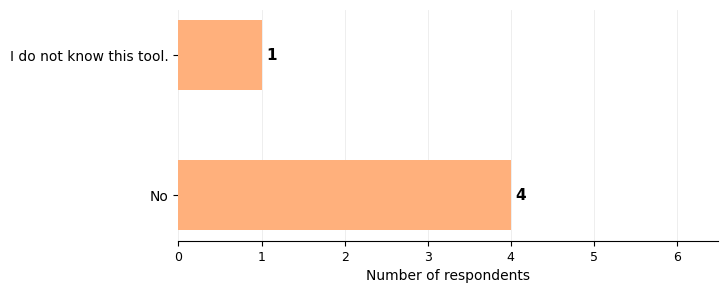

Saved: fig_44_hbfa.png


In [10]:
hb_order = ["I do not know this tool.","No","Yes"]
hb_raw  = simple_counts("Q44")
hb_cnt  = OrderedDict((k, hb_raw[k]) for k in hb_order if k in hb_raw)
for k,v in hb_raw.items():
    if k not in hb_cnt: hb_cnt[k] = v
print(f"Q44 — HBFA (n={sum(hb_cnt.values())}/{N}):")
for k,v in hb_cnt.items(): print(f"  {k}: {v}")
hbar(hb_cnt, "fig_44_hbfa.png", max_x=5)
